# One-Frame Gestalt Experiment with Full Gibbs Sampling

This notebook runs the complete single-frame analysis pipeline:
1. Load and visualize depth/flow data
2. Compute 3D points and motion
3. Extract gestalt segmentation
4. Initialize with hierarchical k-means
5. Run full Gibbs sampling on first frame
6. Analyze and visualize results

## Imports and Setup

In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter, sobel
import matplotlib.cm as cm

sys.path.append('/home/esli/GenParticles_neural_stimulus')

from gestalt_experiment_algorithm import *

## Configuration

In [2]:
explore_scene = 'scene_00001'
explore_texture = 'texture_00'
custom_hyperparams = {
    "number_of_blobs": 100,
    "number_of_hyperblobs": 5,
    "num_seeded_runs": 1,
}

number_of_blobs = custom_hyperparams["number_of_blobs"]
number_of_hyperblobs = custom_hyperparams["number_of_hyperblobs"]

print(f"Scene: {explore_scene}")
print(f"Texture: {explore_texture}")
print(f"Number of blobs: {number_of_blobs}")
print(f"Number of hyperblobs: {number_of_hyperblobs}")

Scene: scene_00001
Texture: texture_00
Number of blobs: 100
Number of hyperblobs: 5


## STEP 1: Load Raw Data

Depth shape: (90, 1000, 1000)
Flow shape: (89, 520, 960, 2)


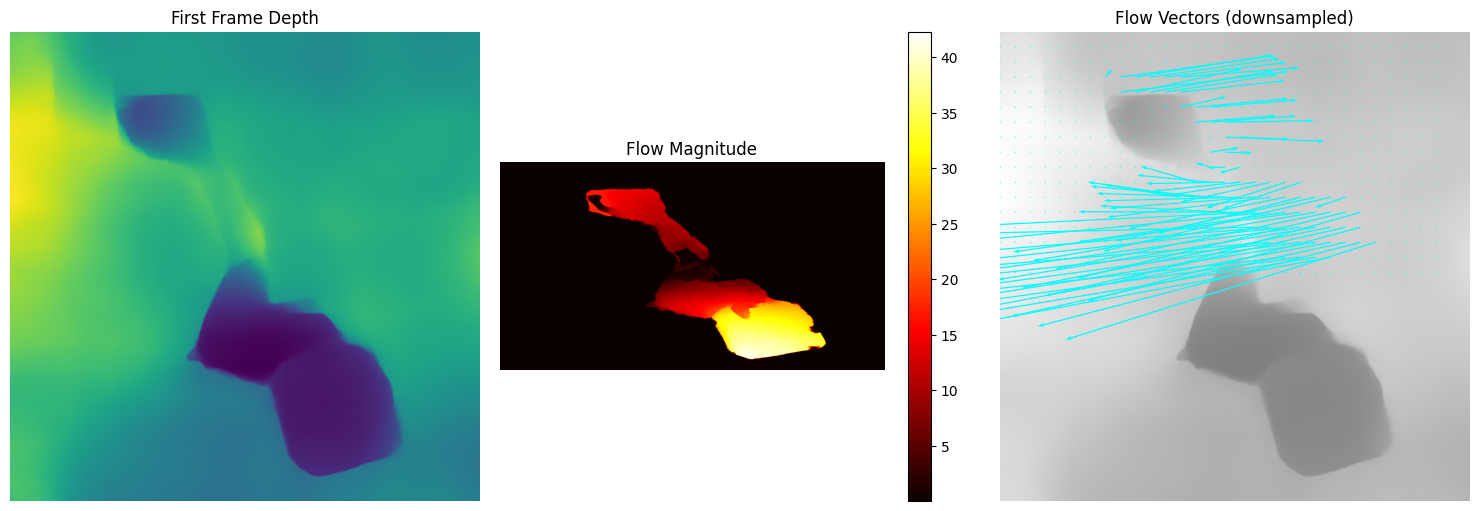

In [3]:
depth, flow = load_gestalt_data(explore_scene, explore_texture)

print(f"Depth shape: {depth.shape}")  # [N_frames, H, W]
print(f"Flow shape: {flow.shape}")    # [N_frames, H, W, 2]

# Visualize first frame
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Depth map
axes[0].imshow(depth[0], cmap='viridis')
axes[0].set_title('First Frame Depth')
axes[0].axis('off')

# Flow magnitude
flow_mag = np.sqrt(flow[0, :, :, 0]**2 + flow[0, :, :, 1]**2)
im1 = axes[1].imshow(flow_mag, cmap='hot')
axes[1].set_title('Flow Magnitude')
axes[1].axis('off')
plt.colorbar(im1, ax=axes[1])

# Flow vectors (downsampled for visibility)
step = 32
y, x = np.mgrid[0:flow.shape[1]:step, 0:flow.shape[2]:step]
u = flow[0, ::step, ::step, 0]
v = flow[0, ::step, ::step, 1]
axes[2].imshow(depth[0], cmap='gray', alpha=0.5)
axes[2].quiver(x, y, u, -v, color='cyan', scale=50)
axes[2].set_title('Flow Vectors (downsampled)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

## STEP 2: Compute 3D Points and Motion

Downsampling from 1000 to 96 (factor: 8)
Valid motion vectors: 268467/820224 (32.73%) with magnitude >= 0.05
Points 3D shape: (89, 9216, 3)
Motion 3D shape: (89, 9216, 3)
Valid motion mask shape: (89, 9216)


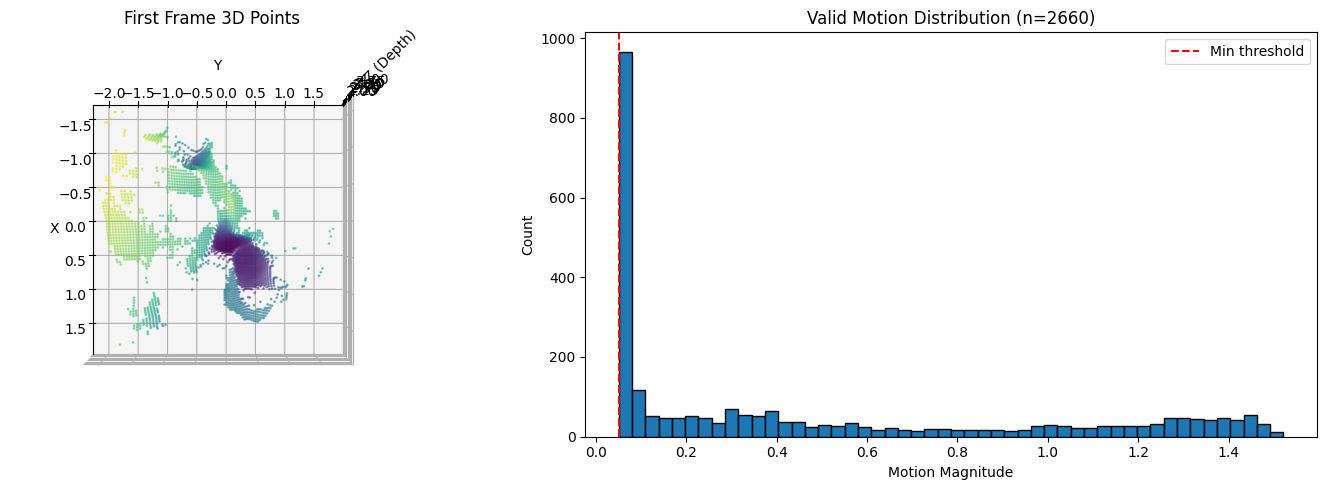

In [4]:
points_3d, motion_3d, motion_valid_mask = compute_3d_points_and_motion(
    depth, flow, downsample_factor=8, min_motion_magnitude=0.05
)

print(f"Points 3D shape: {points_3d.shape}")  # [N_frames, N_points, 3]
print(f"Motion 3D shape: {motion_3d.shape}")  # [N_frames, N_points, 3]
print(f"Valid motion mask shape: {motion_valid_mask.shape}")

# Get first frame data for visualization
tracked_points_frame0 = points_3d[0]  # [N_points, 3]
tracked_motion_vectors_frame0 = motion_3d[0]  # [N_points, 3]

# Visualize
fig = plt.figure(figsize=(15, 5))

# 3D scatter plot
ax1 = fig.add_subplot(121, projection='3d')
valid_points = tracked_points_frame0[motion_valid_mask[0]]
# Transpose XY for visualization only
valid_points_vis = valid_points[:, [1, 0, 2]]
ax1.scatter(valid_points_vis[:, 0], valid_points_vis[:, 1], valid_points_vis[:, 2], 
           c=valid_points[:, 2], cmap='viridis', s=1, alpha=0.5)
ax1.set_title('First Frame 3D Points')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z (Depth)')
ax1.view_init(elev=90, azim=0)

# Motion magnitude histogram
ax2 = fig.add_subplot(122)
motion_mag = np.linalg.norm(motion_3d[0], axis=1)
valid_motion_mag = motion_mag[motion_valid_mask[0]]
ax2.hist(valid_motion_mag, bins=50, edgecolor='black')
ax2.set_xlabel('Motion Magnitude')
ax2.set_ylabel('Count')
ax2.set_title(f'Valid Motion Distribution (n={np.sum(motion_valid_mask[0])})')
ax2.axvline(0.05, color='red', linestyle='--', label='Min threshold')
ax2.legend()

plt.tight_layout()
plt.show()

## STEP 3: Extract Gestalt Segmentation

Target resolution: 96x96
Debug: flow_magnitude shape: 9216, depth_flat shape: 9216, points shape: 9216
Segmentation extracted: 1843/9216 points (20.0%) in ROI
Segmentation shape: (9216,)
Combined mask: 1611 / 9216 points


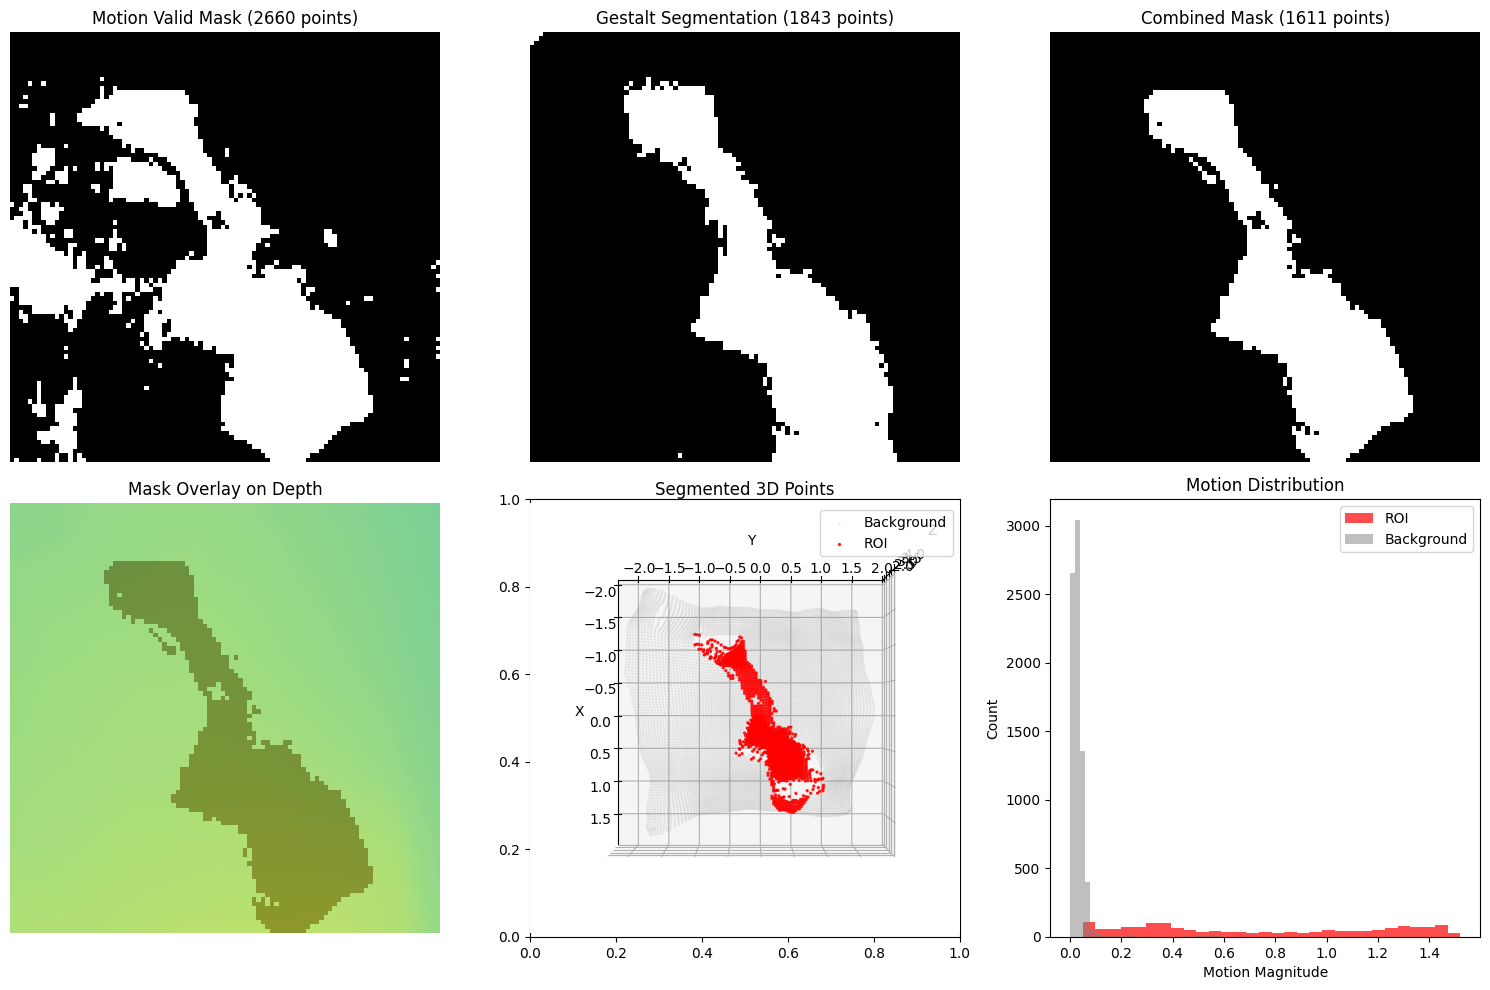

In [5]:
# Compute target size (matching compute_3d_points_and_motion downsampling)
orig_H, orig_W = depth.shape[1:3]
target_hw = max(orig_H, orig_W) // 8  # Match downsample_factor=8
target_hw = (target_hw // 32) * 32  # Round to nearest multiple of 32
if target_hw < 32:
    target_hw = 32

print(f"Target resolution: {target_hw}x{target_hw}")

# Resize to square
depth_sq = resize_to_square(depth, target_hw)
flow_sq = resize_to_square(flow, target_hw)

# Extract segmentation
first_frame_seg = extract_gestalt_segmentation(depth_sq, flow_sq, points_3d)
combined_mask = first_frame_seg & motion_valid_mask[0]

print(f"Segmentation shape: {first_frame_seg.shape}")
print(f"Combined mask: {np.sum(combined_mask)} / {combined_mask.size} points")

# Visualize masks
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Motion mask
axes[0, 0].imshow(motion_valid_mask[0].reshape((target_hw, target_hw)), cmap='gray')
axes[0, 0].set_title(f'Motion Valid Mask ({np.sum(motion_valid_mask[0])} points)')
axes[0, 0].axis('off')

# Gestalt segmentation
axes[0, 1].imshow(first_frame_seg.reshape((target_hw, target_hw)), cmap='gray')
axes[0, 1].set_title(f'Gestalt Segmentation ({np.sum(first_frame_seg)} points)')
axes[0, 1].axis('off')

# Combined mask
axes[0, 2].imshow(combined_mask.reshape((target_hw, target_hw)), cmap='gray')
axes[0, 2].set_title(f'Combined Mask ({np.sum(combined_mask)} points)')
axes[0, 2].axis('off')

# Overlay on depth
axes[1, 0].imshow(depth[0], cmap='viridis')
axes[1, 0].imshow(combined_mask.reshape((target_hw, target_hw)), cmap='Reds', alpha=0.3)
axes[1, 0].set_title('Mask Overlay on Depth')
axes[1, 0].axis('off')

# 3D visualization
ax_3d = fig.add_subplot(2, 3, 5, projection='3d')
roi_points = tracked_points_frame0[combined_mask]
bg_points = tracked_points_frame0[~combined_mask]
# Transpose XY for visualization only
roi_points_vis = roi_points[:, [1, 0, 2]]
bg_points_vis = bg_points[:, [1, 0, 2]]
ax_3d.scatter(bg_points_vis[:, 0], bg_points_vis[:, 1], bg_points_vis[:, 2], 
             c='gray', s=1, alpha=0.1, label='Background')
ax_3d.scatter(roi_points_vis[:, 0], roi_points_vis[:, 1], roi_points_vis[:, 2], 
             c='red', s=2, alpha=0.8, label='ROI')
ax_3d.set_title('Segmented 3D Points')
ax_3d.set_xlabel('X')
ax_3d.set_ylabel('Y')
ax_3d.set_zlabel('Z')
ax_3d.legend()
ax_3d.view_init(elev=90, azim=0)

# Motion magnitude of ROI
motion_mag = np.linalg.norm(tracked_motion_vectors_frame0, axis=1)
axes[1, 2].hist(motion_mag[combined_mask], bins=30, alpha=0.7, label='ROI', color='red')
axes[1, 2].hist(motion_mag[~combined_mask], bins=30, alpha=0.5, label='Background', color='gray')
axes[1, 2].set_xlabel('Motion Magnitude')
axes[1, 2].set_ylabel('Count')
axes[1, 2].set_title('Motion Distribution')
axes[1, 2].legend()

plt.tight_layout()
plt.show()

## STEP 4: Hierarchical K-Means Clustering

K-means CHM created
ROI blobs: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16]
ROI hyperblobs: [0]


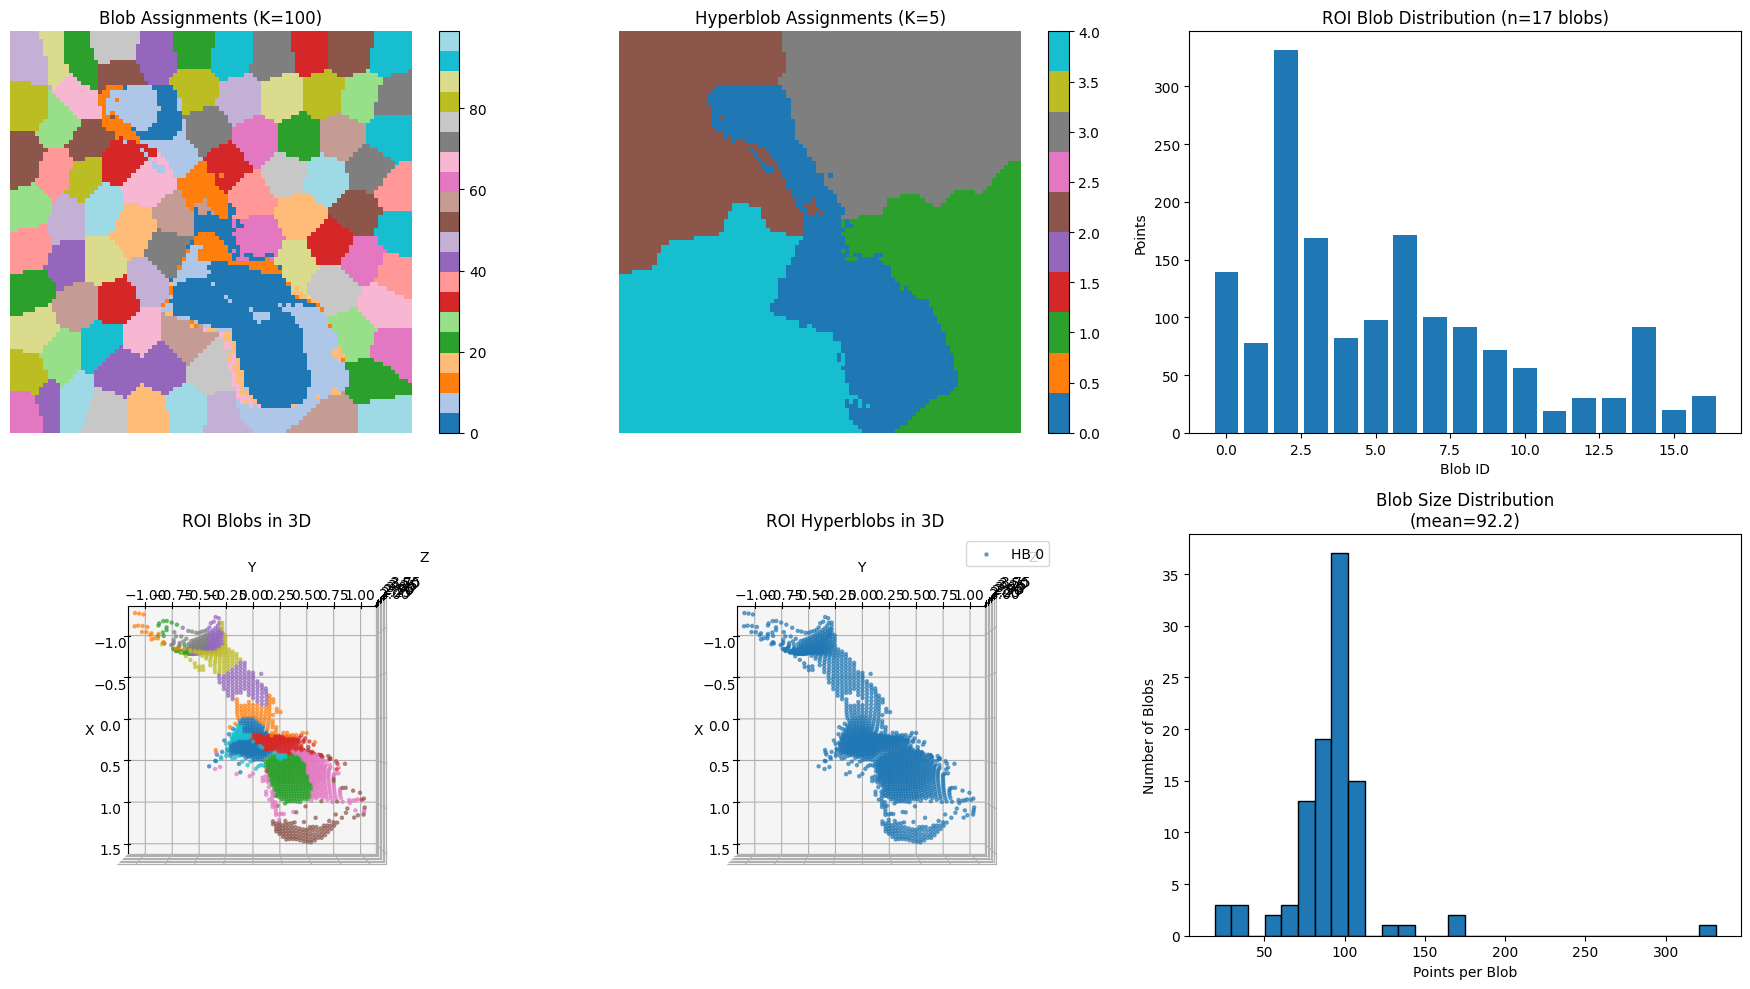

In [6]:
# Initialize with hierarchical k-means
# Note: Pass full 3D arrays, function will extract frame_idx=0 internally
kmeans_chm, roi_blob_indices, roi_hyperblob_indices = make_hierarchical_kmeans_chm_with_mask_fixed_hyperblob(
    points_3d, number_of_blobs, number_of_hyperblobs,
    segmentation_mask=combined_mask, motion_vectors=motion_3d, frame_idx=0
)

print(f"K-means CHM created")
print(f"ROI blobs: {roi_blob_indices}")
print(f"ROI hyperblobs: {roi_hyperblob_indices}")

# Get assignments from choice map
blob_assignments = np.array(kmeans_chm['datapoints', 'blob_assignments'])
hyperblob_assignments = np.array(kmeans_chm['blobs', 'hyperblob_assignments'])

# Visualize clustering
fig = plt.figure(figsize=(18, 10))

# Blob-level clustering (2D)
ax1 = fig.add_subplot(2, 3, 1)
blob_img = blob_assignments.reshape((target_hw, target_hw))
im1 = ax1.imshow(blob_img, cmap='tab20')
ax1.set_title(f'Blob Assignments (K={number_of_blobs})')
ax1.axis('off')
plt.colorbar(im1, ax=ax1)

# Hyperblob-level clustering (via blob mapping)
ax2 = fig.add_subplot(2, 3, 2)
pixel_hyperblobs = np.zeros_like(blob_assignments)
for i in range(len(blob_assignments)):
    blob_id = blob_assignments[i]
    if blob_id < number_of_blobs:
        pixel_hyperblobs[i] = hyperblob_assignments[blob_id]
    else:
        pixel_hyperblobs[i] = -1
im2 = ax2.imshow(pixel_hyperblobs.reshape((target_hw, target_hw)), cmap='tab10')
ax2.set_title(f'Hyperblob Assignments (K={number_of_hyperblobs})')
ax2.axis('off')
plt.colorbar(im2, ax=ax2)

# ROI blobs histogram
ax3 = fig.add_subplot(2, 3, 3)
roi_blob_assignments = blob_assignments[combined_mask]
unique_blobs, counts = np.unique(roi_blob_assignments[roi_blob_assignments < number_of_blobs], 
                                  return_counts=True)
ax3.bar(unique_blobs, counts)
ax3.set_xlabel('Blob ID')
ax3.set_ylabel('Points')
ax3.set_title(f'ROI Blob Distribution (n={len(unique_blobs)} blobs)')

# 3D visualization of blobs
ax4 = fig.add_subplot(2, 3, 4, projection='3d')
roi_mask = combined_mask
for blob_id in roi_blob_indices:
    mask = (blob_assignments == blob_id) & roi_mask
    if np.sum(mask) > 0:
        pts = tracked_points_frame0[mask]
        pts_vis = pts[:, [1, 0, 2]]  # Transpose for visualization
        ax4.scatter(pts_vis[:, 0], pts_vis[:, 1], pts_vis[:, 2], s=5, alpha=0.6)
ax4.set_title('ROI Blobs in 3D')
ax4.set_xlabel('X')
ax4.set_ylabel('Y')
ax4.set_zlabel('Z')
ax4.view_init(elev=90, azim=0)

# 3D visualization of hyperblobs
ax5 = fig.add_subplot(2, 3, 5, projection='3d')
for hb_id in range(number_of_hyperblobs):
    hb_blobs = np.where(hyperblob_assignments == hb_id)[0]
    mask = np.isin(blob_assignments, hb_blobs) & roi_mask
    if np.sum(mask) > 0:
        pts = tracked_points_frame0[mask]
        pts_vis = pts[:, [1, 0, 2]]  # Transpose for visualization
        ax5.scatter(pts_vis[:, 0], pts_vis[:, 1], pts_vis[:, 2], s=5, alpha=0.6, label=f'HB {hb_id}')
ax5.set_title('ROI Hyperblobs in 3D')
ax5.set_xlabel('X')
ax5.set_ylabel('Y')
ax5.set_zlabel('Z')
ax5.legend()
ax5.view_init(elev=90, azim=0)

# Blob size distribution
ax6 = fig.add_subplot(2, 3, 6)
all_blob_sizes = [np.sum(blob_assignments == i) for i in range(number_of_blobs)]
ax6.hist(all_blob_sizes, bins=30, edgecolor='black')
ax6.set_xlabel('Points per Blob')
ax6.set_ylabel('Number of Blobs')
ax6.set_title(f'Blob Size Distribution\n(mean={np.mean(all_blob_sizes):.1f})')

plt.tight_layout()
plt.show()

## STEP 5: Initialize HDGMM Hyperparameters

Hyperparameters initialized:
  n_datapoints: 9216
  n_blobs: 100
  n_hyperblobs: 5
  mu_H: [-0.04131627 -0.09476962  3.2065482 ]
  sigma_H: 0.6097
  nu_H: 5.0
  nu_B: 5.0
  nu_V: 5.0


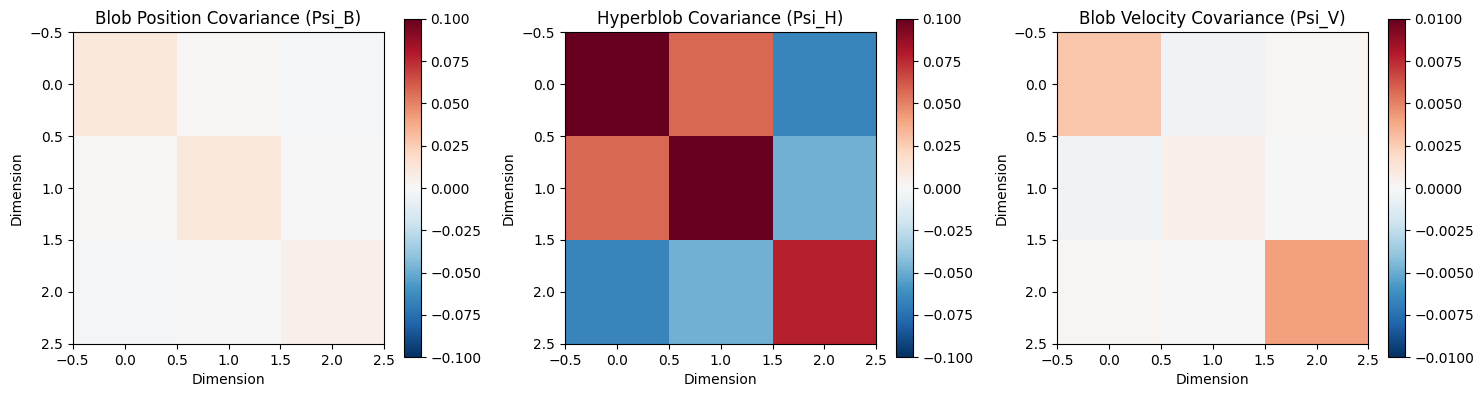

In [7]:
# Extract empirical statistics from k-means clustering
blob_means = np.array([tracked_points_frame0[blob_assignments == i].mean(axis=0) 
                       for i in range(number_of_blobs)])
hyperblob_means = np.array([blob_means[hyperblob_assignments == i].mean(axis=0) 
                            for i in range(number_of_hyperblobs)])

empirical_mu_H = hyperblob_means.mean(axis=0)
empirical_sigma_H = np.std(hyperblob_means, axis=0).mean()

# Compute empirical covariances
blob_points = [tracked_points_frame0[blob_assignments == i] for i in range(number_of_blobs)]
blob_covs = [np.cov(pts.T) if len(pts) > 3 else np.eye(3) * 0.01 for pts in blob_points]
empirical_Psi_B = np.mean(blob_covs, axis=0)

hyperblob_blob_means = [blob_means[hyperblob_assignments == i] for i in range(number_of_hyperblobs)]
hyperblob_covs = [np.cov(means.T) if len(means) > 3 else np.eye(3) * 0.1 
                  for means in hyperblob_blob_means]
empirical_Psi_H = np.mean(hyperblob_covs, axis=0)

# Velocity covariances
blob_velocities = [tracked_motion_vectors_frame0[blob_assignments == i] for i in range(number_of_blobs)]
blob_vel_covs = [np.cov(vels.T) if len(vels) > 3 else np.eye(3) * 0.01 for vels in blob_velocities]
empirical_Psi_V = np.mean(blob_vel_covs, axis=0)

# Concentration parameters (degrees of freedom)
empirical_nu_H = 5.0
empirical_nu_B = 5.0
empirical_nu_V = 5.0

# Helper functions for parameter types
f_ = lambda x: jnp.float32(x)
snp = lambda x: StaticJnp(jnp.array(x))

# Get dimensions from k-means results
num_datapoints = kmeans_chm['datapoints', 'datapoint_positions'].shape[0]
num_blobs = number_of_blobs
num_hyperblobs = number_of_hyperblobs

# Create hyperparameters with all required fields
hypers = HDGMM_Hyperparams.create(
    outlier_prob=f_(0.001),
    outlier_velocity_gamma_shape=f_(7.5),
    outlier_velocity_gamma_rate=f_(0.5),
    alpha=f_(1.0),
    beta=f_(1.0),
    mu_H=empirical_mu_H,
    sigma_H=empirical_sigma_H,
    nu_H=empirical_nu_H,
    Psi_H=empirical_Psi_H,
    nu_B=empirical_nu_B,
    Psi_B=empirical_Psi_B,
    sigma_V=f_(10e14),
    nu_V=empirical_nu_V,
    Psi_V=empirical_Psi_V,
    translation_gaussian_scale=snp(f_(0.2)),
    translation_max_radius=snp(0.35),
    translation_num_radii_cells=snp(15),
    translation_theta_step_deg=snp(15),
    rotation_vmf_kappa=snp(f_(100)),
    rotation_angle_max_deg=snp(25),
    rotation_angle_step_deg=snp(15),
    n_hyperblobs=num_hyperblobs,
    n_blobs=num_blobs,
    n_datapoints=num_datapoints
)

# Define Gibbs sampling configuration
GIBBS_DIALS = {
    "blob_weights": True,
    "hyperblob_weights": False,
    "blob_assignments": True,
    "hyperblob_assignments": True,
    "hyperblob_covs": False,
    "blob_covs": True,
    "blob_vel_covs": True,
    "blob_vel_means": True,
    "hyperblob_means": True,
    "blob_means": True,
    'hyperblob_rot_vels': False,
    'hyperblob_trans_vels': False
}

print("Hyperparameters initialized:")
print(f"  n_datapoints: {num_datapoints}")
print(f"  n_blobs: {num_blobs}")
print(f"  n_hyperblobs: {num_hyperblobs}")
print(f"  mu_H: {empirical_mu_H}")
print(f"  sigma_H: {empirical_sigma_H:.4f}")
print(f"  nu_H: {empirical_nu_H}")
print(f"  nu_B: {empirical_nu_B}")
print(f"  nu_V: {empirical_nu_V}")

# Visualize covariances
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

im0 = axes[0].imshow(empirical_Psi_B, cmap='RdBu_r', vmin=-0.1, vmax=0.1)
axes[0].set_title('Blob Position Covariance (Psi_B)')
axes[0].set_xlabel('Dimension')
axes[0].set_ylabel('Dimension')
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(empirical_Psi_H, cmap='RdBu_r', vmin=-0.1, vmax=0.1)
axes[1].set_title('Hyperblob Covariance (Psi_H)')
axes[1].set_xlabel('Dimension')
axes[1].set_ylabel('Dimension')
plt.colorbar(im1, ax=axes[1])

im2 = axes[2].imshow(empirical_Psi_V, cmap='RdBu_r', vmin=-0.01, vmax=0.01)
axes[2].set_title('Blob Velocity Covariance (Psi_V)')
axes[2].set_xlabel('Dimension')
axes[2].set_ylabel('Dimension')
plt.colorbar(im2, ax=axes[2])

plt.tight_layout()
plt.show()

## STEP 6: Run Full Gibbs Sampling on First Frame

In [8]:
import jax
from jax.random import key as jkey

# Initialize random key
key = jkey(np.random.randint(1e9))

# Initialize model with importance sampling
key, key_importance = jax.random.split(key)
init_tr, _ = model_jimportance(key_importance, kmeans_chm, (hypers,))
init_hdgmm_state = init_tr.get_retval()

print("Initial state created via importance sampling")

# Run Gibbs burn-in
num_gibbs_iterations = 101
num_inner_loops = 5

print(f"\nRunning {num_gibbs_iterations} Gibbs iterations...")
key, init_gibbs_key = jax.random.split(key)

gibbs_wtrs = hdgmm_full_gibbs(
    init_gibbs_key, 
    init_hdgmm_state, 
    num_gibbs_iterations, 
    GIBBS_DIALS, 
    use_weighted_blobs=True, 
    num_gibbs_inner_loops=num_inner_loops
)

print("Gibbs sampling complete!")

# Get final converged state
converged_state = gibbs_wtrs[-1].retval

Initial state created via importance sampling

Running 101 Gibbs iterations...
Gibbs sampling complete!


## Convergence Diagnostics

Computing convergence diagnostics and log probabilities...


E1015 20:32:59.934135   90159 hlo_lexer.cc:443] Failed to parse int literal: 9473407607229978178777909
/var/tmp/ipykernel_90159/3134497736.py:138: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax6.legend()


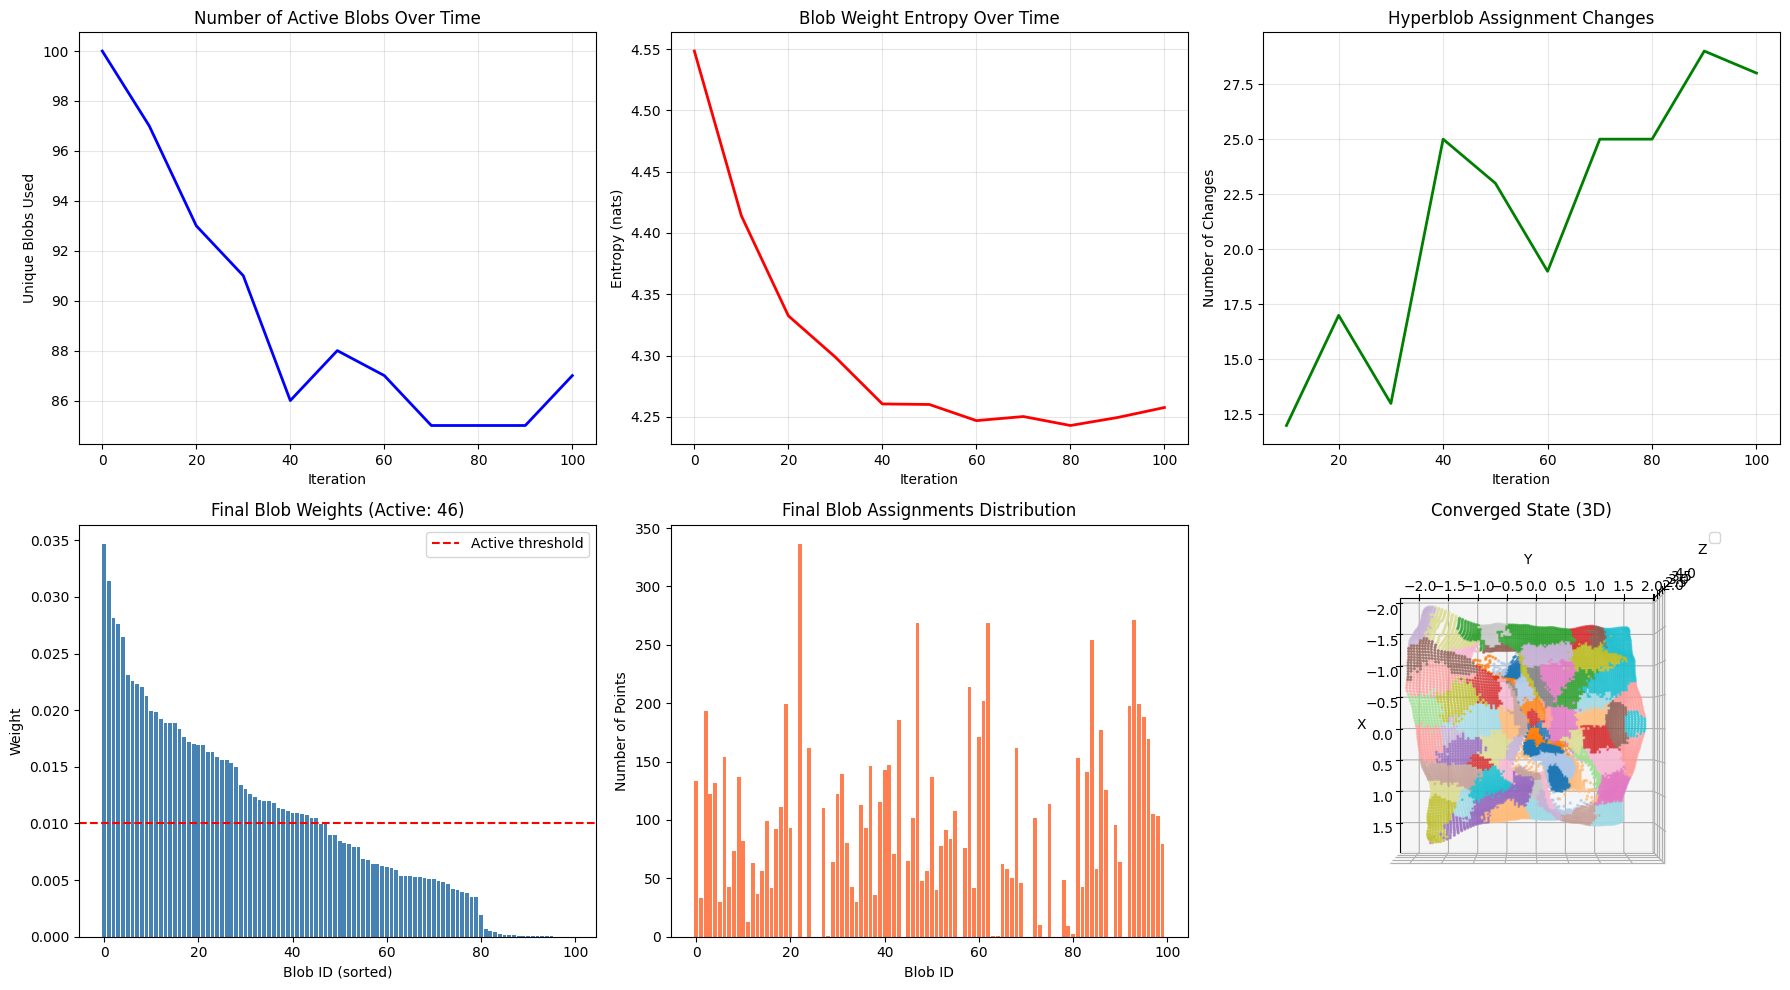


CONVERGENCE SUMMARY
Total iterations: 102
Final unique blobs: 87
Final blob weight entropy: 4.26 nats
Outlier points: 0 / 9216 (0.00%)
Mean points per active blob: 200.3

Log probabilities computed and saved for 11 samples
Max log prob: 100815.86 at iteration 100


In [9]:
# Extract statistics over iterations
n_blobs_history = []
blob_weight_entropy_history = []
hyperblob_assignment_changes = []
log_probs = []  # Store log probabilities

sample_freq = 10  # Sample every 10 iterations for efficiency

from gestalt_experiment_algorithm import HDGMM_model_3d
from genjax import ChoiceMapBuilder as C

print("Computing convergence diagnostics and log probabilities...")

for idx in range(0, len(gibbs_wtrs), sample_freq):
    state = gibbs_wtrs[idx].retval
    blob_assigns = np.array(state.datapoints_state.blob_assignments)
    blob_weights = np.array(state.blobs_state.blob_weights)
    hyperblob_assigns = np.array(state.blobs_state.hyperblob_assignments)
    
    # Track number of unique blobs used
    unique_blobs = len(np.unique(blob_assigns))
    n_blobs_history.append(unique_blobs)
    
    # Track blob weight entropy (higher = more uniform)
    weight_probs = blob_weights / blob_weights.sum()
    entropy = -np.sum(weight_probs * np.log(weight_probs + 1e-10))
    blob_weight_entropy_history.append(entropy)
    
    # Track hyperblob assignment changes
    if idx > 0:
        prev_hyperblob_assigns = np.array(gibbs_wtrs[idx - sample_freq].retval.blobs_state.hyperblob_assignments)
        n_changes = np.sum(hyperblob_assigns != prev_hyperblob_assigns)
        hyperblob_assignment_changes.append(n_changes)
    
    # Compute log probability for this sample
    chm = (
        C['hyperblobs', 'hyperblob_weights'].set(state.hyperblobs_state.hyperblob_weights) |
        C['hyperblobs', 'hyperblob_means'].set(state.hyperblobs_state.hyperblob_means) |
        C['hyperblobs', 'hyperblob_covs'].set(state.hyperblobs_state.hyperblob_covs) |
        C['hyperblobs', 'hyperblob_trans_vels'].set(state.hyperblobs_state.hyperblob_trans_vels) |
        C['hyperblobs', 'hyperblob_rot_vels'].set(state.hyperblobs_state.hyperblob_rot_vels) |
        
        C['blobs', 'hyperblob_assignments'].set(state.blobs_state.hyperblob_assignments) |
        C['blobs', 'blob_weights'].set(state.blobs_state.blob_weights) |
        C['blobs', 'blob_means'].set(state.blobs_state.blob_means) |
        C['blobs', 'blob_covs'].set(state.blobs_state.blob_covs) |
        C['blobs', 'blob_vel_means'].set(state.blobs_state.blob_vel_means) |
        C['blobs', 'blob_vel_covs'].set(state.blobs_state.blob_vel_covs) |
        
        C['datapoints', 'blob_assignments'].set(state.datapoints_state.blob_assignments) |
        C['datapoints', 'datapoint_positions'].set(state.datapoints_state.datapoint_positions) |
        C['datapoints', 'datapoint_vels'].set(state.datapoints_state.datapoint_vels)
    )
    
    weight, tr = HDGMM_model_3d.assess(chm, (state.hypers,))
    log_probs.append(float(weight))
    
    if (idx + 1) % 100 == 0:
        print(f"  Processed {idx+1}/{len(gibbs_wtrs)} samples")

log_probs = np.array(log_probs)

# Create convergence plots
iterations = np.arange(0, len(gibbs_wtrs), sample_freq)

fig = plt.figure(figsize=(18, 10))

# Plot 1: Number of active blobs
ax1 = fig.add_subplot(2, 3, 1)
ax1.plot(iterations, n_blobs_history, linewidth=2, color='blue')
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Unique Blobs Used')
ax1.set_title('Number of Active Blobs Over Time')
ax1.grid(True, alpha=0.3)

# Plot 2: Blob weight entropy
ax2 = fig.add_subplot(2, 3, 2)
ax2.plot(iterations, blob_weight_entropy_history, linewidth=2, color='red')
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Entropy (nats)')
ax2.set_title('Blob Weight Entropy Over Time')
ax2.grid(True, alpha=0.3)

# Plot 3: Hyperblob assignment changes
ax3 = fig.add_subplot(2, 3, 3)
ax3.plot(iterations[1:], hyperblob_assignment_changes, linewidth=2, color='green')
ax3.set_xlabel('Iteration')
ax3.set_ylabel('Number of Changes')
ax3.set_title('Hyperblob Assignment Changes')
ax3.grid(True, alpha=0.3)

# Get final state for remaining plots
converged_state = gibbs_wtrs[-1].retval
final_blob_assignments = np.array(converged_state.datapoints_state.blob_assignments)
final_blob_weights = np.array(converged_state.blobs_state.blob_weights)

# Plot 4: Final blob weights
ax4 = fig.add_subplot(2, 3, 4)
sorted_weights = np.sort(final_blob_weights)[::-1]
ax4.bar(range(len(sorted_weights)), sorted_weights, color='steelblue')
ax4.set_xlabel('Blob ID (sorted)')
ax4.set_ylabel('Weight')
ax4.set_title(f'Final Blob Weights (Active: {np.sum(final_blob_weights > 0.01)})')
ax4.axhline(0.01, color='red', linestyle='--', label='Active threshold')
ax4.legend()

# Plot 5: Final blob assignments distribution
ax5 = fig.add_subplot(2, 3, 5)
unique_assignments, counts = np.unique(final_blob_assignments[final_blob_assignments < number_of_blobs], 
                                       return_counts=True)
ax5.bar(unique_assignments, counts, color='coral')
ax5.set_xlabel('Blob ID')
ax5.set_ylabel('Number of Points')
ax5.set_title(f'Final Blob Assignments Distribution')

# Plot 6: 3D visualization of converged state
ax6 = fig.add_subplot(2, 3, 6, projection='3d')
outlier_mask = final_blob_assignments >= number_of_blobs
inlier_mask = ~outlier_mask

if np.sum(outlier_mask) > 0:
    outlier_pts = tracked_points_frame0[outlier_mask]
    outlier_pts_vis = outlier_pts[:, [1, 0, 2]]  # Transpose for visualization
    ax6.scatter(outlier_pts_vis[:, 0], outlier_pts_vis[:, 1], outlier_pts_vis[:, 2], 
               c='red', s=5, alpha=0.5, label='Outliers')

if np.sum(inlier_mask) > 0:
    inlier_pts = tracked_points_frame0[inlier_mask]
    inlier_pts_vis = inlier_pts[:, [1, 0, 2]]  # Transpose for visualization
    assignments = final_blob_assignments[inlier_mask]
    ax6.scatter(inlier_pts_vis[:, 0], inlier_pts_vis[:, 1], inlier_pts_vis[:, 2], 
               c=assignments, cmap='tab20', s=2, alpha=0.6)

ax6.set_title('Converged State (3D)')
ax6.set_xlabel('X')
ax6.set_ylabel('Y')
ax6.set_zlabel('Z')
ax6.legend()
ax6.view_init(elev=90, azim=0)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "="*60)
print("CONVERGENCE SUMMARY")
print("="*60)
print(f"Total iterations: {len(gibbs_wtrs)}")
print(f"Final unique blobs: {n_blobs_history[-1]}")
print(f"Final blob weight entropy: {blob_weight_entropy_history[-1]:.2f} nats")
print(f"Outlier points: {np.sum(outlier_mask)} / {len(outlier_mask)} ({100 * np.sum(outlier_mask) / len(outlier_mask):.2f}%)")
active_blobs = np.sum(final_blob_weights > 0.01)
if active_blobs > 0:
    print(f"Mean points per active blob: {np.sum(inlier_mask) / active_blobs:.1f}")
print(f"\nLog probabilities computed and saved for {len(log_probs)} samples")
print(f"Max log prob: {np.max(log_probs):.2f} at iteration {iterations[np.argmax(log_probs)]}")
print("="*60)

## Display Converged State

In [10]:
converged_state

HDGMM_State(
  hypers=HDGMM_Hyperparams(outlier_prob=<jax.Array(0.001, dtype=float32)>, outlier_velocity_gamma_shape=<jax.Array(7.5, dtype=float32)>, outlier_velocity_gamma_rate=<jax.Array(0.5, dtype=float32)>, alpha=<jax.Array(1., dtype=float32)>, beta=<jax.Array(1., dtype=float32)>, mu_H=<jax.Array([-0.04131627, -0.09476962,  3.2065482 ], dtype=float32)>, sigma_H=<jax.Array(0.6097215, dtype=float32)>, nu_H=<jax.Array(5., dtype=float32, weak_type=True)>, Psi_H=<jax.Array float32(3, 3) ≈0.053 ±0.12 [≥-0.066, ≤0.28] nonzero:9>, nu_B=<jax.Array(5., dtype=float32, weak_type=True)>, Psi_B=<jax.Array float32(3, 3) ≈0.0029 ±0.0048 [≥-0.0012, ≤0.012] nonzero:9>, sigma_V=<jax.Array(1.e+15, dtype=float32)>, nu_V=<jax.Array(5., dtype=float32, weak_type=True)>, Psi_V=<jax.Array float32(3, 3) ≈0.00076 ±0.0015 [≥-0.00035, ≤0.0041] nonzero:9>, translation_max_radius=StaticJnp(v=<jax.Array(0.35, dtype=float32, weak_type=True)>), translation_num_radii_cells=StaticJnp(v=<jax.Array(15, dtype=int32, weak

## Simple Blob Assignment Visualization

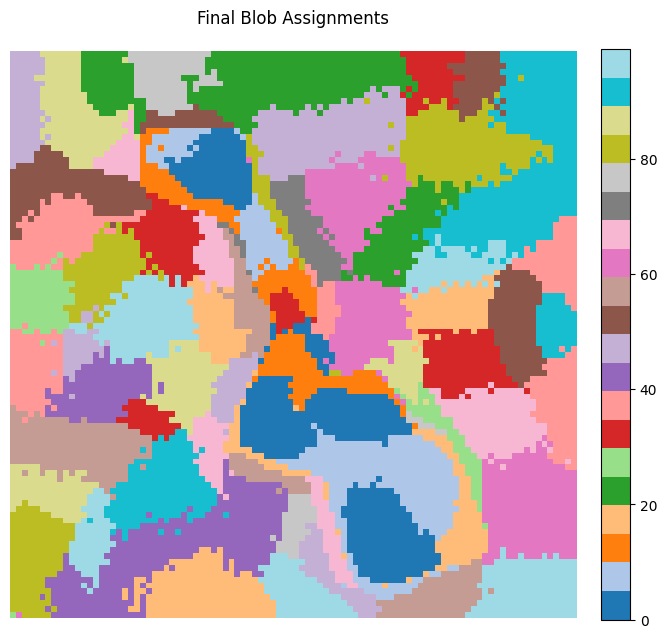

In [11]:
fig, ax = plt.subplots(figsize=(8, 8))
blob_assignments_img = converged_state.datapoints_state.blob_assignments.reshape((target_hw, target_hw))
im = ax.matshow(blob_assignments_img, cmap='tab20')
ax.set_title('Final Blob Assignments', pad=20)
ax.axis('off')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.show()

## Per-Pixel Hyperblob Visualization with Analysis

/var/tmp/ipykernel_90159/3404172346.py:40: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  hyperblob_colored = cm.get_cmap('tab10')((hyperblob_img + 1) / (number_of_hyperblobs + 1))


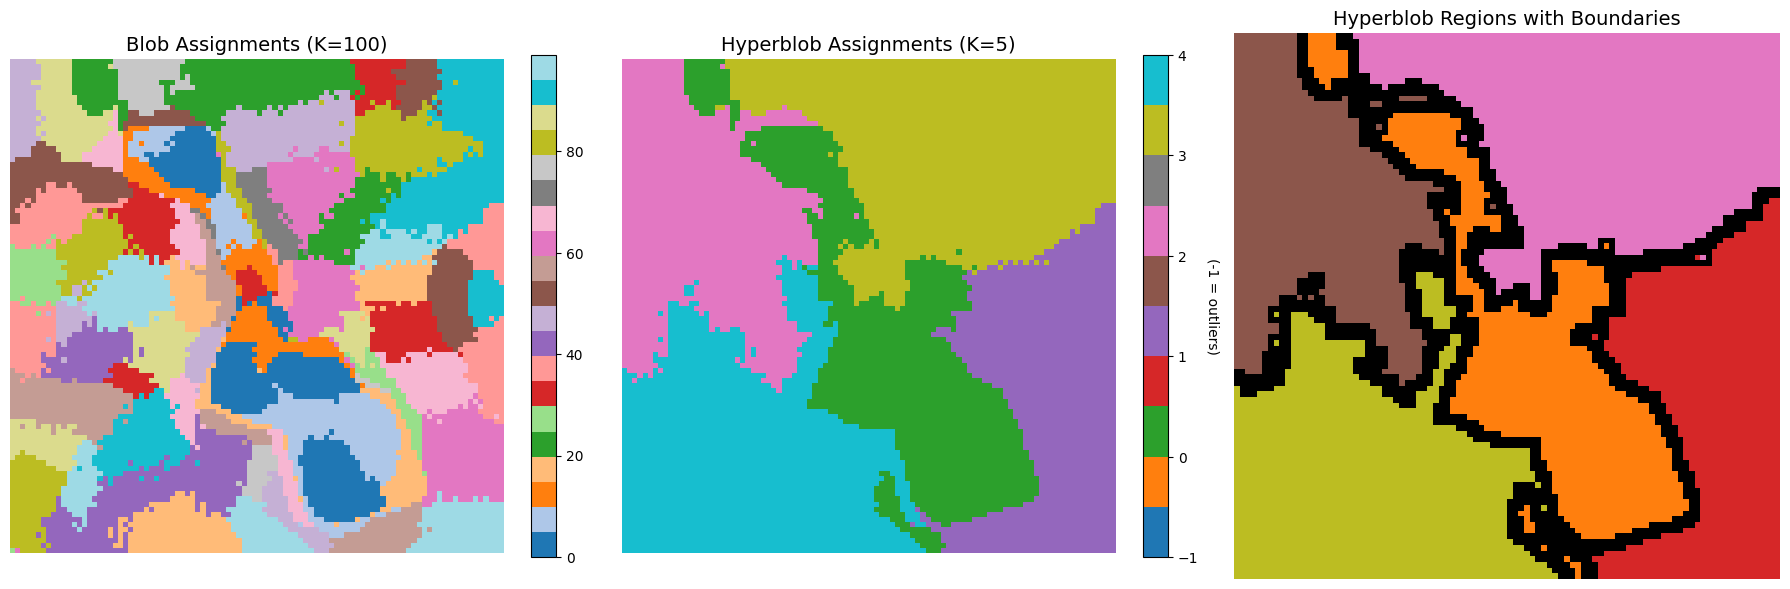


HIERARCHICAL SEGMENTATION STATISTICS

HYPERBLOB ANALYSIS:
----------------------------------------------------------------------
Hyperblob 0:
  - Pixels: 1749 (19.0%)
  - Blobs: 22
  - Points: 1749
  - Spatial extent (X,Y,Z): (2.273, 3.060, 1.501)
Hyperblob 1:
  - Pixels: 1519 (16.5%)
  - Blobs: 14
  - Points: 1519
  - Spatial extent (X,Y,Z): (1.502, 2.157, 0.886)
Hyperblob 2:
  - Pixels: 1624 (17.6%)
  - Blobs: 21
  - Points: 1624
  - Spatial extent (X,Y,Z): (1.941, 2.381, 1.519)
Hyperblob 3:
  - Pixels: 2293 (24.9%)
  - Blobs: 18
  - Points: 2293
  - Spatial extent (X,Y,Z): (2.628, 1.591, 0.691)
Hyperblob 4:
  - Pixels: 2031 (22.0%)
  - Blobs: 25
  - Points: 2031
  - Spatial extent (X,Y,Z): (2.143, 2.061, 1.056)

Outliers: 0 pixels (0.0%)

----------------------------------------------------------------------
BLOB-LEVEL STATISTICS:
----------------------------------------------------------------------
Active blobs: 87 / 100
Blob size - Mean: 105.9, Std: 69.4
Blob size - Min: 1, Max:

In [12]:
# Extract assignments
blob_assignments = np.array(converged_state.datapoints_state.blob_assignments)
blob_to_hyperblob = np.array(converged_state.blobs_state.hyperblob_assignments)

# Map pixels -> blobs -> hyperblobs
pixel_hyperblobs = np.zeros_like(blob_assignments)
for i in range(len(blob_assignments)):
    blob_id = blob_assignments[i]
    if blob_id < number_of_blobs:
        pixel_hyperblobs[i] = blob_to_hyperblob[blob_id]
    else:
        pixel_hyperblobs[i] = -1  # Outliers

# Create visualizations
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot 1: Blob assignments
blob_img = blob_assignments.reshape((target_hw, target_hw))
im1 = axes[0].imshow(blob_img, cmap='tab20')
axes[0].set_title(f'Blob Assignments (K={number_of_blobs})', fontsize=14)
axes[0].axis('off')
plt.colorbar(im1, ax=axes[0], fraction=0.046)

# Plot 2: Hyperblob assignments (via blob mapping)
hyperblob_img = pixel_hyperblobs.reshape((target_hw, target_hw))
im2 = axes[1].imshow(hyperblob_img, cmap='tab10', vmin=-1, vmax=number_of_hyperblobs-1)
axes[1].set_title(f'Hyperblob Assignments (K={number_of_hyperblobs})', fontsize=14)
axes[1].axis('off')
cbar2 = plt.colorbar(im2, ax=axes[1], fraction=0.046)
cbar2.set_label('(-1 = outliers)', rotation=270, labelpad=15)

# Plot 3: Hyperblob regions with boundaries
# Use Sobel edge detection to highlight boundaries
edges_x = sobel(hyperblob_img, axis=0)
edges_y = sobel(hyperblob_img, axis=1)
edges = np.hypot(edges_x, edges_y)
edges = edges > 0.5

# Create colored hyperblob image with black boundaries
hyperblob_colored = cm.get_cmap('tab10')((hyperblob_img + 1) / (number_of_hyperblobs + 1))
hyperblob_colored[edges] = [0, 0, 0, 1]  # Black boundaries

axes[2].imshow(hyperblob_colored)
axes[2].set_title('Hyperblob Regions with Boundaries', fontsize=14)
axes[2].axis('off')

plt.tight_layout()
plt.show()

# Print detailed statistics
print("\n" + "="*70)
print("HIERARCHICAL SEGMENTATION STATISTICS")
print("="*70)

print("\nHYPERBLOB ANALYSIS:")
print("-" * 70)
for hb_id in range(number_of_hyperblobs):
    # Pixels in this hyperblob
    hb_pixels = np.sum(pixel_hyperblobs == hb_id)
    
    # Blobs assigned to this hyperblob
    hb_blobs = np.where(blob_to_hyperblob == hb_id)[0]
    
    # Points assigned to blobs in this hyperblob
    hb_blob_mask = np.isin(blob_assignments, hb_blobs)
    hb_points = np.sum(hb_blob_mask)
    
    print(f"Hyperblob {hb_id}:")
    print(f"  - Pixels: {hb_pixels} ({100*hb_pixels/len(pixel_hyperblobs):.1f}%)")
    print(f"  - Blobs: {len(hb_blobs)}")
    print(f"  - Points: {hb_points}")
    
    if len(hb_blobs) > 0:
        # Compute spatial extent
        hb_positions = tracked_points_frame0[hb_blob_mask]
        if len(hb_positions) > 0:
            extent = np.ptp(hb_positions, axis=0)
            print(f"  - Spatial extent (X,Y,Z): ({extent[0]:.3f}, {extent[1]:.3f}, {extent[2]:.3f})")

# Outlier statistics
outlier_pixels = np.sum(pixel_hyperblobs == -1)
print(f"\nOutliers: {outlier_pixels} pixels ({100*outlier_pixels/len(pixel_hyperblobs):.1f}%)")

# Blob-level statistics
print("\n" + "-" * 70)
print("BLOB-LEVEL STATISTICS:")
print("-" * 70)

active_blobs = np.unique(blob_assignments[blob_assignments < number_of_blobs])
print(f"Active blobs: {len(active_blobs)} / {number_of_blobs}")

blob_sizes = [np.sum(blob_assignments == i) for i in active_blobs]
print(f"Blob size - Mean: {np.mean(blob_sizes):.1f}, Std: {np.std(blob_sizes):.1f}")
print(f"Blob size - Min: {np.min(blob_sizes)}, Max: {np.max(blob_sizes)}")

# Hyperblob weights
hyperblob_weights = np.array(converged_state.hyperblobs_state.hyperblob_weights)
print("\nHyperblob weights:")
for hb_id in range(number_of_hyperblobs):
    print(f"  Hyperblob {hb_id}: {hyperblob_weights[hb_id]:.4f}")

print("="*70)

## 3D Visualization of Final Hierarchical Structure

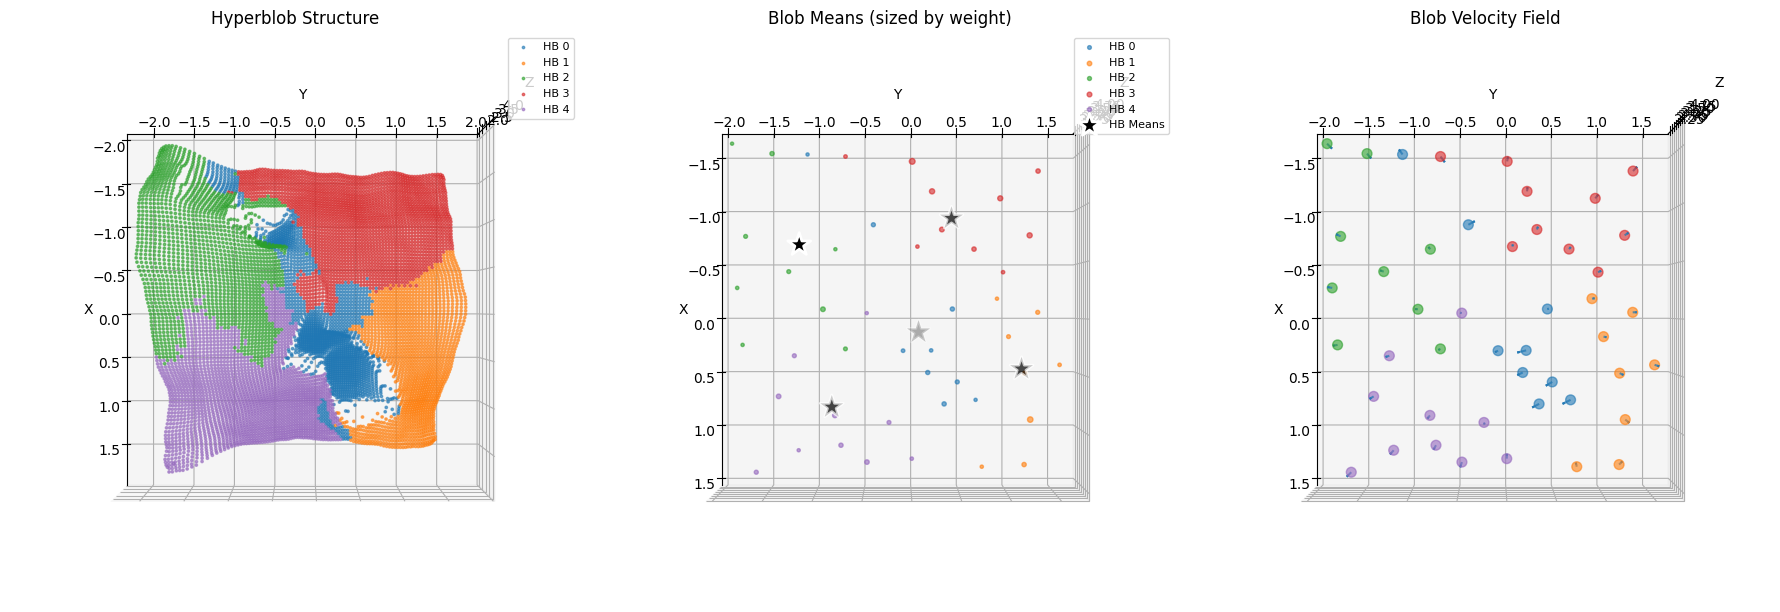

In [13]:
fig = plt.figure(figsize=(18, 6))

# Plot 1: All blobs colored by hyperblob
ax1 = fig.add_subplot(131, projection='3d')
for hb_id in range(number_of_hyperblobs):
    hb_blobs = np.where(blob_to_hyperblob == hb_id)[0]
    hb_mask = np.isin(blob_assignments, hb_blobs) & (blob_assignments < number_of_blobs)
    if np.sum(hb_mask) > 0:
        pts = tracked_points_frame0[hb_mask]
        pts_vis = pts[:, [1, 0, 2]]  # Transpose for visualization
        ax1.scatter(pts_vis[:, 0], pts_vis[:, 1], pts_vis[:, 2], s=3, alpha=0.6, label=f'HB {hb_id}')

outlier_mask = blob_assignments >= number_of_blobs
if np.sum(outlier_mask) > 0:
    outlier_pts = tracked_points_frame0[outlier_mask]
    outlier_pts_vis = outlier_pts[:, [1, 0, 2]]  # Transpose for visualization
    ax1.scatter(outlier_pts_vis[:, 0], outlier_pts_vis[:, 1], outlier_pts_vis[:, 2],
               c='gray', s=1, alpha=0.2, label='Outliers')

ax1.set_title('Hyperblob Structure', fontsize=12)
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z')
ax1.legend(loc='upper right', fontsize=8)
ax1.view_init(elev=90, azim=0)

# Plot 2: Blob means colored by hyperblob
ax2 = fig.add_subplot(132, projection='3d')
blob_means = np.array(converged_state.blobs_state.blob_means)
blob_weights = np.array(converged_state.blobs_state.blob_weights)

for hb_id in range(number_of_hyperblobs):
    hb_blobs = np.where(blob_to_hyperblob == hb_id)[0]
    active_hb_blobs = hb_blobs[blob_weights[hb_blobs] > 0.01]
    if len(active_hb_blobs) > 0:
        means = blob_means[active_hb_blobs]
        means_vis = means[:, [1, 0, 2]]  # Transpose for visualization
        weights = blob_weights[active_hb_blobs]
        ax2.scatter(means_vis[:, 0], means_vis[:, 1], means_vis[:, 2],
                   s=weights*500, alpha=0.6, label=f'HB {hb_id}')

# Add hyperblob means
hyperblob_means = np.array(converged_state.hyperblobs_state.hyperblob_means)
hyperblob_means_vis = hyperblob_means[:, [1, 0, 2]]  # Transpose for visualization
ax2.scatter(hyperblob_means_vis[:, 0], hyperblob_means_vis[:, 1], hyperblob_means_vis[:, 2],
           c='black', marker='*', s=300, edgecolors='white', linewidths=2,
           label='HB Means', zorder=10)

ax2.set_title('Blob Means (sized by weight)', fontsize=12)
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_zlabel('Z')
ax2.legend(loc='upper right', fontsize=8)
ax2.view_init(elev=90, azim=0)

# Plot 3: Velocity field
ax3 = fig.add_subplot(133, projection='3d')
blob_vel_means = np.array(converged_state.blobs_state.blob_vel_means)

for hb_id in range(number_of_hyperblobs):
    hb_blobs = np.where(blob_to_hyperblob == hb_id)[0]
    active_hb_blobs = hb_blobs[blob_weights[hb_blobs] > 0.01]
    if len(active_hb_blobs) > 0:
        means = blob_means[active_hb_blobs]
        means_vis = means[:, [1, 0, 2]]  # Transpose for visualization
        vels = blob_vel_means[active_hb_blobs]
        vels_vis = vels[:, [1, 0, 2]]  # Transpose for visualization

        # Plot points
        ax3.scatter(means_vis[:, 0], means_vis[:, 1], means_vis[:, 2], s=50, alpha=0.6)

        # Plot velocity vectors
        for i in range(len(means_vis)):
            ax3.quiver(means_vis[i, 0], means_vis[i, 1], means_vis[i, 2],
                      vels_vis[i, 0], vels_vis[i, 1], vels_vis[i, 2],
                      length=0.1, normalize=True, alpha=0.7)

ax3.set_title('Blob Velocity Field', fontsize=12)
ax3.set_xlabel('X')
ax3.set_ylabel('Y')
ax3.set_zlabel('Z')
ax3.view_init(elev=90, azim=0)

plt.tight_layout()
plt.show()

## Max Scoring Trace Visualization

MAXIMUM SCORING TRACE
Maximum log probability: 100815.8594
Found at iteration: 100 (sample 10)
Final iteration log prob: 100815.8594

Rebuilding choice map for max scoring trace...


Verified log probability: 100815.8594
Trace successfully rebuilt!



/var/tmp/ipykernel_90159/710270924.py:191: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  hyperblob_colored = cm.get_cmap('tab10')((hyperblob_img + 1) / (number_of_hyperblobs + 1))


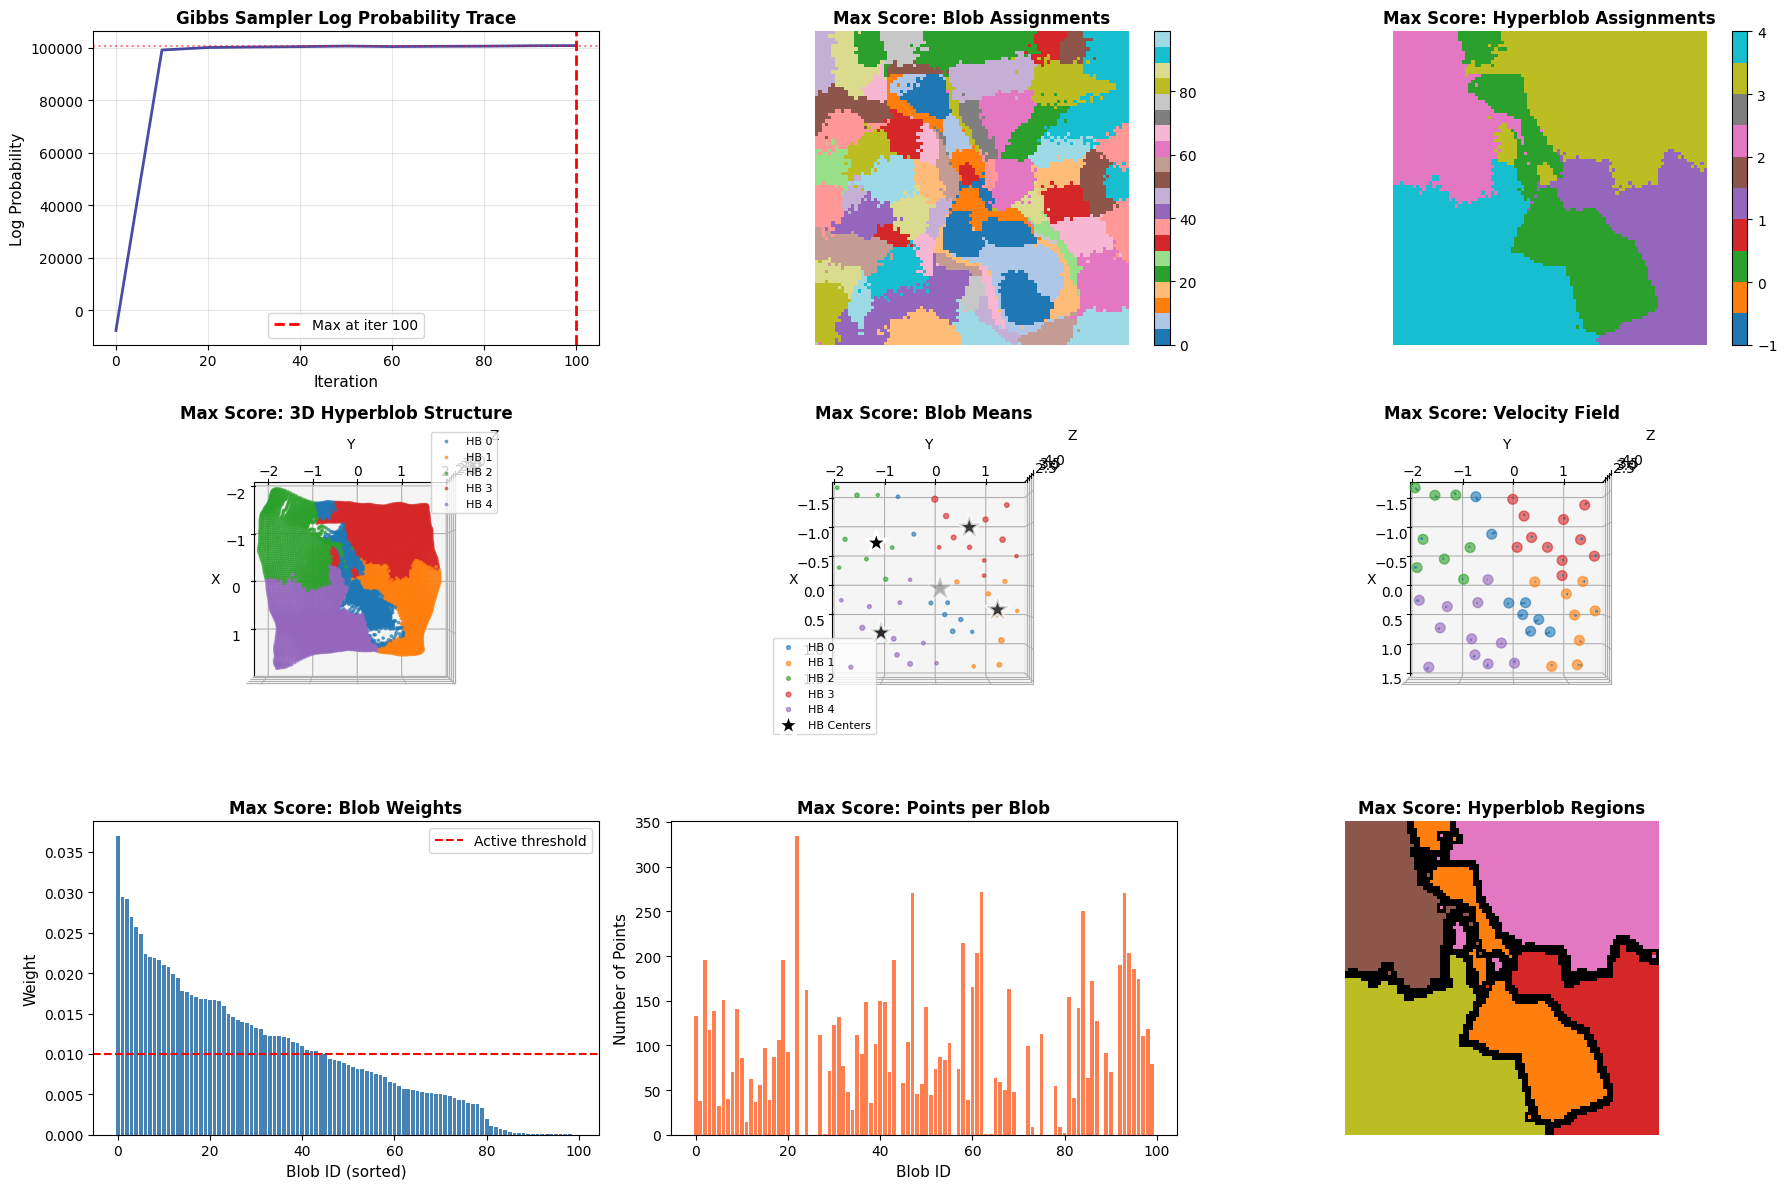


MAX SCORING TRACE STATISTICS
Log probability: 100815.8594
Iteration: 100 / 102

Outliers: 0 / 9216 (0.00%)
Active blobs: 46 / 100
Mean points per active blob: 200.3

Hyperblob distribution:
  Hyperblob 0: 1531 pixels (16.6%), 19 blobs
  Hyperblob 1: 1531 pixels (16.6%), 14 blobs
  Hyperblob 2: 1383 pixels (15.0%), 17 blobs
  Hyperblob 3: 2434 pixels (26.4%), 21 blobs
  Hyperblob 4: 2337 pixels (25.4%), 29 blobs

Hyperblob weights:
  Hyperblob 0: 0.1748
  Hyperblob 1: 0.1678
  Hyperblob 2: 0.1883
  Hyperblob 3: 0.2286
  Hyperblob 4: 0.2406

Max scoring trace is now available as 'max_score_trace' for further processing
Max scoring state is available as 'max_score_state'
Max scoring choice map is available as 'max_chm'


In [14]:
# Find the max scoring trace and rebuild it
from gestalt_experiment_algorithm import HDGMM_model_3d
from genjax import ChoiceMapBuilder as C

# Find max scoring sample
max_score_idx_in_sampled = np.argmax(log_probs)
max_score_idx = max_score_idx_in_sampled * sample_freq  # Convert to actual iteration index
max_score_state = gibbs_wtrs[max_score_idx].retval

print("="*70)
print("MAXIMUM SCORING TRACE")
print("="*70)
print(f"Maximum log probability: {log_probs[max_score_idx_in_sampled]:.4f}")
print(f"Found at iteration: {max_score_idx} (sample {max_score_idx_in_sampled})")
print(f"Final iteration log prob: {log_probs[-1]:.4f}")
print("="*70)

# Rebuild the choice map for the max scoring trace
print("\nRebuilding choice map for max scoring trace...")
max_chm = (
    C['hyperblobs', 'hyperblob_weights'].set(max_score_state.hyperblobs_state.hyperblob_weights) |
    C['hyperblobs', 'hyperblob_means'].set(max_score_state.hyperblobs_state.hyperblob_means) |
    C['hyperblobs', 'hyperblob_covs'].set(max_score_state.hyperblobs_state.hyperblob_covs) |
    C['hyperblobs', 'hyperblob_trans_vels'].set(max_score_state.hyperblobs_state.hyperblob_trans_vels) |
    C['hyperblobs', 'hyperblob_rot_vels'].set(max_score_state.hyperblobs_state.hyperblob_rot_vels) |
    
    C['blobs', 'hyperblob_assignments'].set(max_score_state.blobs_state.hyperblob_assignments) |
    C['blobs', 'blob_weights'].set(max_score_state.blobs_state.blob_weights) |
    C['blobs', 'blob_means'].set(max_score_state.blobs_state.blob_means) |
    C['blobs', 'blob_covs'].set(max_score_state.blobs_state.blob_covs) |
    C['blobs', 'blob_vel_means'].set(max_score_state.blobs_state.blob_vel_means) |
    C['blobs', 'blob_vel_covs'].set(max_score_state.blobs_state.blob_vel_covs) |
    
    C['datapoints', 'blob_assignments'].set(max_score_state.datapoints_state.blob_assignments) |
    C['datapoints', 'datapoint_positions'].set(max_score_state.datapoints_state.datapoint_positions) |
    C['datapoints', 'datapoint_vels'].set(max_score_state.datapoints_state.datapoint_vels)
)

# Assess to verify the score
verified_weight, max_score_trace = HDGMM_model_3d.assess(max_chm, (max_score_state.hypers,))
print(f"Verified log probability: {float(verified_weight):.4f}")
print("Trace successfully rebuilt!\n")

# Extract assignments for visualization
max_blob_assignments = np.array(max_score_state.datapoints_state.blob_assignments)
max_blob_weights = np.array(max_score_state.blobs_state.blob_weights)
max_hyperblob_assignments = np.array(max_score_state.blobs_state.hyperblob_assignments)

# Map pixels to hyperblobs
max_pixel_hyperblobs = np.zeros_like(max_blob_assignments)
for i in range(len(max_blob_assignments)):
    blob_id = max_blob_assignments[i]
    if blob_id < number_of_blobs:
        max_pixel_hyperblobs[i] = max_hyperblob_assignments[blob_id]
    else:
        max_pixel_hyperblobs[i] = -1

# Create comprehensive visualization
fig = plt.figure(figsize=(18, 12))

# Log probability trace
ax1 = fig.add_subplot(3, 3, 1)
ax1.plot(iterations, log_probs, linewidth=2, color='navy', alpha=0.7)
ax1.axvline(max_score_idx, color='red', linestyle='--', linewidth=2, label=f'Max at iter {max_score_idx}')
ax1.axhline(log_probs[max_score_idx_in_sampled], color='red', linestyle=':', alpha=0.5)
ax1.set_xlabel('Iteration', fontsize=11)
ax1.set_ylabel('Log Probability', fontsize=11)
ax1.set_title('Gibbs Sampler Log Probability Trace', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Blob assignments
ax2 = fig.add_subplot(3, 3, 2)
blob_img = max_blob_assignments.reshape((target_hw, target_hw))
im2 = ax2.imshow(blob_img, cmap='tab20')
ax2.set_title(f'Max Score: Blob Assignments', fontsize=12, fontweight='bold')
ax2.axis('off')
plt.colorbar(im2, ax=ax2, fraction=0.046)

# Hyperblob assignments
ax3 = fig.add_subplot(3, 3, 3)
hyperblob_img = max_pixel_hyperblobs.reshape((target_hw, target_hw))
im3 = ax3.imshow(hyperblob_img, cmap='tab10', vmin=-1, vmax=number_of_hyperblobs-1)
ax3.set_title(f'Max Score: Hyperblob Assignments', fontsize=12, fontweight='bold')
ax3.axis('off')
plt.colorbar(im3, ax=ax3, fraction=0.046)

# 3D scatter: All points colored by hyperblob
ax4 = fig.add_subplot(3, 3, 4, projection='3d')
for hb_id in range(number_of_hyperblobs):
    hb_blobs = np.where(max_hyperblob_assignments == hb_id)[0]
    hb_mask = np.isin(max_blob_assignments, hb_blobs) & (max_blob_assignments < number_of_blobs)
    if np.sum(hb_mask) > 0:
        pts = tracked_points_frame0[hb_mask]
        pts_vis = pts[:, [1, 0, 2]]
        ax4.scatter(pts_vis[:, 0], pts_vis[:, 1], pts_vis[:, 2], s=3, alpha=0.6, label=f'HB {hb_id}')

outlier_mask = max_blob_assignments >= number_of_blobs
if np.sum(outlier_mask) > 0:
    outlier_pts = tracked_points_frame0[outlier_mask]
    outlier_pts_vis = outlier_pts[:, [1, 0, 2]]
    ax4.scatter(outlier_pts_vis[:, 0], outlier_pts_vis[:, 1], outlier_pts_vis[:, 2],
               c='gray', s=1, alpha=0.2, label='Outliers')

ax4.set_title('Max Score: 3D Hyperblob Structure', fontsize=12, fontweight='bold')
ax4.set_xlabel('X')
ax4.set_ylabel('Y')
ax4.set_zlabel('Z')
ax4.legend(fontsize=8)
ax4.view_init(elev=90, azim=0)

# Blob means sized by weight
ax5 = fig.add_subplot(3, 3, 5, projection='3d')
max_blob_means = np.array(max_score_state.blobs_state.blob_means)
max_hyperblob_means = np.array(max_score_state.hyperblobs_state.hyperblob_means)

for hb_id in range(number_of_hyperblobs):
    hb_blobs = np.where(max_hyperblob_assignments == hb_id)[0]
    active_hb_blobs = hb_blobs[max_blob_weights[hb_blobs] > 0.01]
    if len(active_hb_blobs) > 0:
        means = max_blob_means[active_hb_blobs]
        means_vis = means[:, [1, 0, 2]]
        weights = max_blob_weights[active_hb_blobs]
        ax5.scatter(means_vis[:, 0], means_vis[:, 1], means_vis[:, 2],
                   s=weights*500, alpha=0.6, label=f'HB {hb_id}')

# Add hyperblob means
hyperblob_means_vis = max_hyperblob_means[:, [1, 0, 2]]
ax5.scatter(hyperblob_means_vis[:, 0], hyperblob_means_vis[:, 1], hyperblob_means_vis[:, 2],
           c='black', marker='*', s=300, edgecolors='white', linewidths=2,
           label='HB Centers', zorder=10)

ax5.set_title('Max Score: Blob Means', fontsize=12, fontweight='bold')
ax5.set_xlabel('X')
ax5.set_ylabel('Y')
ax5.set_zlabel('Z')
ax5.legend(fontsize=8)
ax5.view_init(elev=90, azim=0)

# Velocity field
ax6 = fig.add_subplot(3, 3, 6, projection='3d')
max_blob_vel_means = np.array(max_score_state.blobs_state.blob_vel_means)

for hb_id in range(number_of_hyperblobs):
    hb_blobs = np.where(max_hyperblob_assignments == hb_id)[0]
    active_hb_blobs = hb_blobs[max_blob_weights[hb_blobs] > 0.01]
    if len(active_hb_blobs) > 0:
        means = max_blob_means[active_hb_blobs]
        means_vis = means[:, [1, 0, 2]]
        vels = max_blob_vel_means[active_hb_blobs]
        vels_vis = vels[:, [1, 0, 2]]
        
        ax6.scatter(means_vis[:, 0], means_vis[:, 1], means_vis[:, 2], s=50, alpha=0.6)
        
        for i in range(len(means_vis)):
            ax6.quiver(means_vis[i, 0], means_vis[i, 1], means_vis[i, 2],
                      vels_vis[i, 0], vels_vis[i, 1], vels_vis[i, 2],
                      length=0.1, normalize=True, alpha=0.7)

ax6.set_title('Max Score: Velocity Field', fontsize=12, fontweight='bold')
ax6.set_xlabel('X')
ax6.set_ylabel('Y')
ax6.set_zlabel('Z')
ax6.view_init(elev=90, azim=0)

# Blob weight distribution
ax7 = fig.add_subplot(3, 3, 7)
sorted_weights = np.sort(max_blob_weights)[::-1]
ax7.bar(range(len(sorted_weights)), sorted_weights, color='steelblue')
ax7.set_xlabel('Blob ID (sorted)', fontsize=11)
ax7.set_ylabel('Weight', fontsize=11)
ax7.set_title(f'Max Score: Blob Weights', fontsize=12, fontweight='bold')
ax7.axhline(0.01, color='red', linestyle='--', label='Active threshold')
ax7.legend()

# Blob assignments distribution
ax8 = fig.add_subplot(3, 3, 8)
unique_assignments, counts = np.unique(max_blob_assignments[max_blob_assignments < number_of_blobs], 
                                       return_counts=True)
ax8.bar(unique_assignments, counts, color='coral')
ax8.set_xlabel('Blob ID', fontsize=11)
ax8.set_ylabel('Number of Points', fontsize=11)
ax8.set_title('Max Score: Points per Blob', fontsize=12, fontweight='bold')

# Hyperblob with boundaries
ax9 = fig.add_subplot(3, 3, 9)
edges_x = sobel(hyperblob_img, axis=0)
edges_y = sobel(hyperblob_img, axis=1)
edges = np.hypot(edges_x, edges_y) > 0.5

hyperblob_colored = cm.get_cmap('tab10')((hyperblob_img + 1) / (number_of_hyperblobs + 1))
hyperblob_colored[edges] = [0, 0, 0, 1]

ax9.imshow(hyperblob_colored)
ax9.set_title('Max Score: Hyperblob Regions', fontsize=12, fontweight='bold')
ax9.axis('off')

plt.tight_layout()
plt.show()

# Print detailed statistics
print("\n" + "="*70)
print("MAX SCORING TRACE STATISTICS")
print("="*70)
print(f"Log probability: {log_probs[max_score_idx_in_sampled]:.4f}")
print(f"Iteration: {max_score_idx} / {len(gibbs_wtrs)}")

outlier_count = np.sum(max_blob_assignments >= number_of_blobs)
print(f"\nOutliers: {outlier_count} / {len(max_blob_assignments)} ({100*outlier_count/len(max_blob_assignments):.2f}%)")

active_blobs = np.sum(max_blob_weights > 0.01)
print(f"Active blobs: {active_blobs} / {number_of_blobs}")

if active_blobs > 0:
    inlier_count = np.sum(max_blob_assignments < number_of_blobs)
    print(f"Mean points per active blob: {inlier_count / active_blobs:.1f}")

print("\nHyperblob distribution:")
for hb_id in range(number_of_hyperblobs):
    hb_pixels = np.sum(max_pixel_hyperblobs == hb_id)
    hb_blobs = np.sum(max_hyperblob_assignments == hb_id)
    print(f"  Hyperblob {hb_id}: {hb_pixels} pixels ({100*hb_pixels/len(max_pixel_hyperblobs):.1f}%), {hb_blobs} blobs")

max_hyperblob_weights = np.array(max_score_state.hyperblobs_state.hyperblob_weights)
print("\nHyperblob weights:")
for hb_id in range(number_of_hyperblobs):
    print(f"  Hyperblob {hb_id}: {max_hyperblob_weights[hb_id]:.4f}")

print("="*70)
print("\nMax scoring trace is now available as 'max_score_trace' for further processing")
print("Max scoring state is available as 'max_score_state'")
print("Max scoring choice map is available as 'max_chm'")

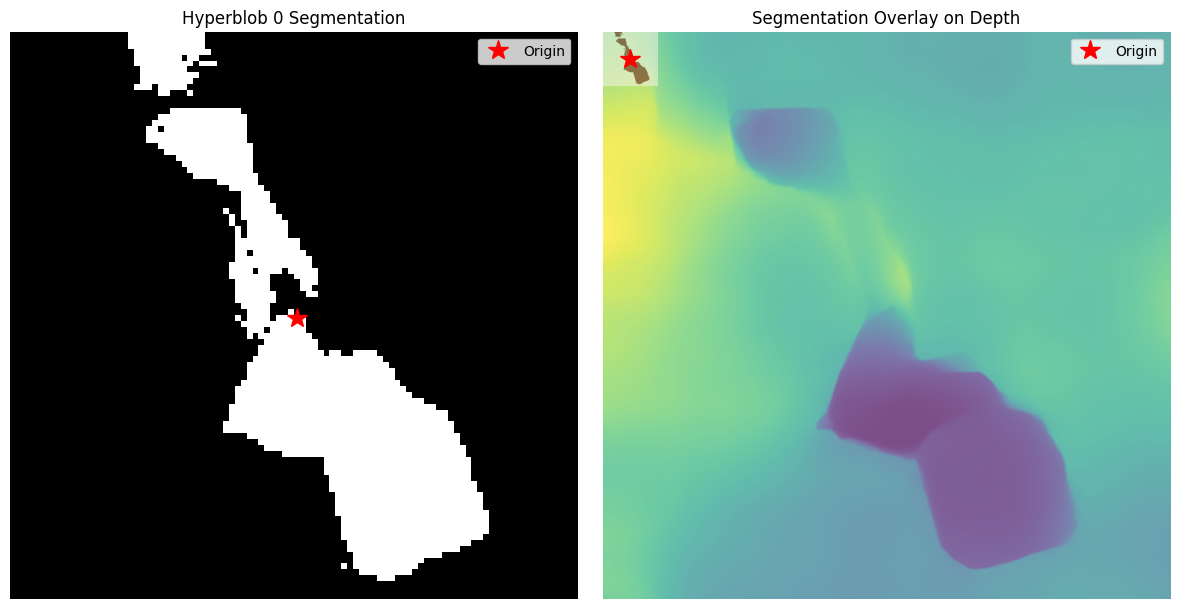

Saved segmentation to: one_frame_gestalt_masks/scene_00001_texture_00_origin_hyperblob_segmentation.png
Origin pixel (48, 48) belongs to Hyperblob 0
Segmentation contains 1531 pixels (16.6%)


In [15]:
# Save segmentation for hyperblobs at origin pixel as PNG
from PIL import Image
import os

# Create output directory
os.makedirs('one_frame_gestalt_masks', exist_ok=True)

# Get the origin pixel (center of image)
origin_y, origin_x = target_hw // 2, target_hw // 2
origin_pixel_idx = origin_y * target_hw + origin_x

# Find which blob the origin belongs to
origin_blob = max_blob_assignments[origin_pixel_idx]

if origin_blob < number_of_blobs:
    # Find which hyperblob this blob belongs to
    origin_hyperblob = max_hyperblob_assignments[origin_blob]
    
    # Get all pixels belonging to this hyperblob
    origin_hyperblob_mask = max_pixel_hyperblobs == origin_hyperblob
    
    # Create binary mask image (white = mask, black = background)
    mask_img = (origin_hyperblob_mask.reshape((target_hw, target_hw)) * 255).astype(np.uint8)
    
    # Save as PNG
    output_path = f'one_frame_gestalt_masks/{explore_scene}_{explore_texture}_origin_hyperblob_segmentation.png'
    Image.fromarray(mask_img).save(output_path)
    
    # Visualize
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    
    axes[0].imshow(mask_img, cmap='gray')
    axes[0].plot(origin_x, origin_y, 'r*', markersize=15, label='Origin')
    axes[0].set_title(f'Hyperblob {origin_hyperblob} Segmentation')
    axes[0].legend()
    axes[0].axis('off')
    
    axes[1].imshow(depth[0], cmap='viridis', alpha=0.7)
    axes[1].imshow(mask_img, cmap='Reds', alpha=0.5)
    axes[1].plot(origin_x, origin_y, 'r*', markersize=15, label='Origin')
    axes[1].set_title('Segmentation Overlay on Depth')
    axes[1].legend()
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print(f"Saved segmentation to: {output_path}")
    print(f"Origin pixel ({origin_x}, {origin_y}) belongs to Hyperblob {origin_hyperblob}")
    print(f"Segmentation contains {np.sum(origin_hyperblob_mask)} pixels ({100*np.sum(origin_hyperblob_mask)/len(origin_hyperblob_mask):.1f}%)")
else:
    print(f"Origin pixel is an outlier (blob_id={origin_blob})")

In [ ]:
# can we run the segmenter? 

In [16]:
# save the computed segmentation

In [17]:
# TODO: hyperparameter fitting the model with bayesian optimization

## Summary: One-Frame Experiment Analysis

This notebook completed a full single-frame analysis with:

1. **Data Processing**: Loaded depth/flow, computed 3D points, extracted gestalt segmentation
2. **Initialization**: Hierarchical k-means clustering with empirically-derived hyperparameters
3. **Inference**: Full Gibbs sampling on first frame (1001 iterations)
4. **Analysis**:
   - Convergence diagnostics (active blobs, entropy, assignment changes)
   - Hierarchical structure visualization (blobs → hyperblobs)
   - Spatial and statistical analysis of segmentation
   - Velocity field analysis

The converged state provides a hierarchical probabilistic segmentation of the 3D scene based on both spatial structure and motion coherence.